<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Video_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

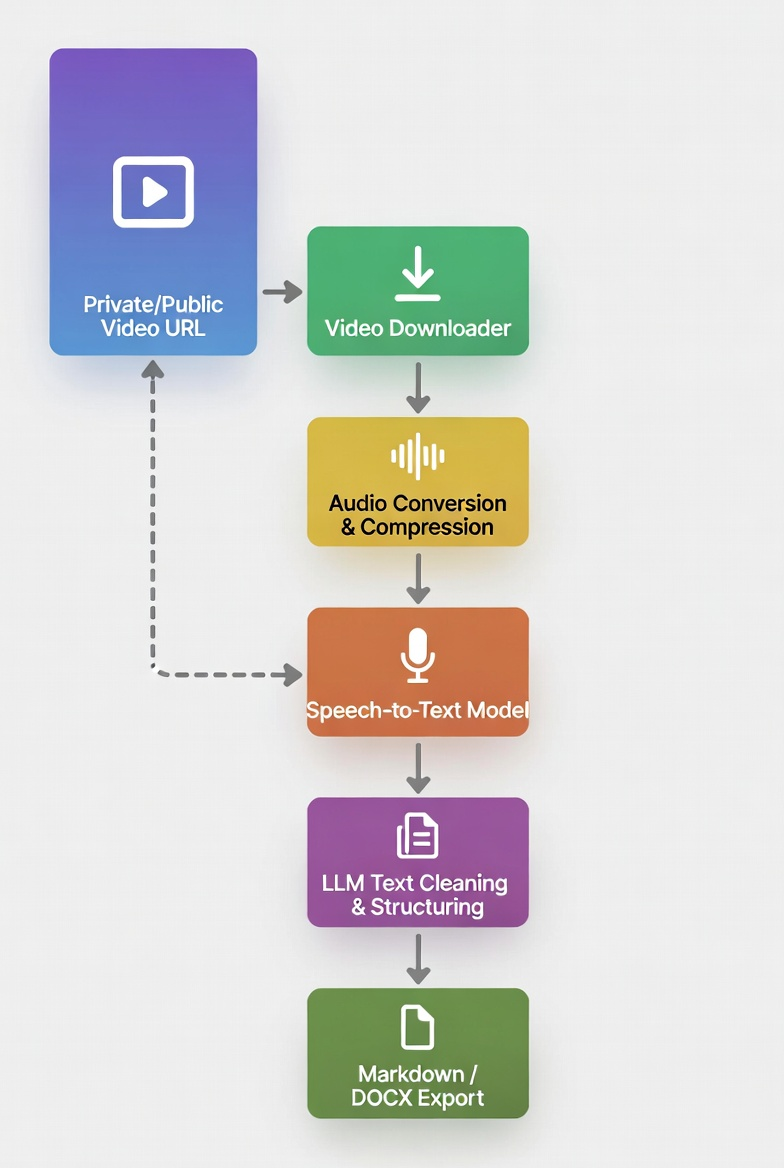


In [ ]:
import torch
torch.cuda.is_available() # make sure it's true for GPU since it's much faster

In [ ]:
!pip install -q openai-whisper

In [ ]:
!pip install -q yt-dlp
!apt-get install -y ffmpeg

In [ ]:
file_name = 'lecture2and3'
header="""
https://kaf.elearning.unimib.it/
"""
url="""
https://www.kaltura.com/p/2351962/sp/235196200/playManifest/entryId/1_4txjn2mw/protocol/https/format/applehttp/flavorIds/1_7c5qejx0,1_08xphzb6/ks/djJ8MjM1MTk2Mnw2tmZUPd1ln_7NwZ0WdQZ7RM2RmISjSsoPKKfFlHjLhBQls25WBjZHWSv2dXmIe0Lv5HjZuN3ItxcYQRVQ7lqrfrUYv78ZJtWwXMMkEewjQTf7J-27zDxE8X4WM1ZyLw33tX8ru2ySo6a8UWSxuU2F7DQ0FBvA_IcYJYhY-hUC5QROn85Y0BGY0Ao_1qKq2VQJlHgpU6tOKH-Wak5c9CkiX2SNI6kn1qzEP1KtoZPn3Pkjd2S5D7PtMjIDny6glKaDYYSXEY1zo4UQoJESYg0MMdiJEvb7qsNypKzoefo65HnLSyon9qp3uD4lPow1GCJVEZ1XuvB3govE96JswJNkY61Blt1EmUbynSGeXgbbcy8z6X2fWh1IYM0bRecTxTBES6XXll6Ve4o7ZDVW-tAfKqzQqCb_-QCJ-Kb-IY1Om8tDzeiOS7jlf6fvMWc0iz6er0-1WPYM5ycuNhpQKTESrjlKx2MplxmmxMPD2efUnuQeYL7URFJt37R5Op2X5j6Q7sIuNEGcM44QkZrm_xVUfaFEZA6q4scywci_6MSEGA==/a.m3u8
"""



*   Make sure audio format is correct (mp4, mpt3, mov, opus, ...)
*   Quality of your audio as small as it is it download faster(32K, 64K)
*   Compress the audio to 16kbps(24kbps, 32kbps)



In [ ]:
# download the audio
!yt-dlp \
  --downloader ffmpeg \
  --hls-use-mpegts \
  --add-header "Referer:{header}" \
  -x \
  --audio-format opus \
  --audio-quality 24K \
  --postprocessor-args "-ac 1 -ar 16000" \
  -o "{file_name}.%(ext)s" \
  "{url}"

In [ ]:
# speed up -> convert to wav once

!ffmpeg -i {file_name}.opus -ar 16000 -ac 1 {file_name}.wav # make sure the extention mutch to your audio (.opus, .wav, .mp3)

In [ ]:
# Chunk the wav - each chank 10 minuts(600s)
!ffmpeg -i {file_name}.wav -f segment -segment_time 600 -c copy chunk_%03d.wav # again check for the extention

### Transcribe chunks

In [ ]:
import whisper
from pathlib import Path

In [ ]:
# optimize inference of whisper to have a better performance
model = whisper.load_model("tiny")

In [ ]:

full_text = []

for audio in sorted(Path(".").glob("chunk_*.wav")):
    # Make sure fp16=False if you are not using GPU
    # fp16 -> half-precision(faster & less memory)
    result = model.transcribe(str(audio), fp16=True) # True only for GPU
    full_text.append(result["text"])

final_text = "\n".join(full_text)

In [ ]:
final_text[:500]

" fine. So, good morning, I am going to increase volume a little bit. So, today as we said, we are going to discuss about the electric field and we start from the electric force. The fact that people were aware about the existence of the electric force forces, it's something that comes from a very ancient time. And in fact, simple observation can demonstrate that there is some type of force that arises. When, for example, a rod that is made of glass is rubbed with silk. And when this happens, the"

 🔑 **Important!**

**I will be using `langchain` from `PaddleOCR` because in the future I want to integrate OCR, and PaddleOCR**
* if you don't then just use the normal `langchain`

In [ ]:
# Install all functionalities, such as document parsing, document understanding,
# document translation, and key information extraction
!pip install "paddleocr[all]"

In [ ]:
# You need to install paddlepaddle superatedly appart from paddlleocr othe
# or you could just !pip install "paddleocr[all]@git+https://github.com/PaddlePaddle/PaddleOCR.git"
# Make sure the paddle version matches to paddleOCR version
!pip install paddlepaddle==3.2.0

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
# from langchain.agents import AgentExecutor

In [ ]:
# your .env format
#OPENAI_API_KEY="your_open_ai_api_key or any other LLM"
import os
from dotenv import load_dotenv
# Load environment variable from .env
_ = load_dotenv(override=True)

In [ ]:
# Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        # gpt-4o-mini: good for text cleanup, rewriting, formatting, speed
        # gpt-5-mini: good for reasoning-heavy tasks, planning, logic
        model="gpt-4o-mini",
        temperature=0 #  higher temperature more creative
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


In [ ]:
cleaning_prompt = f"""
You are given text extracted from an audio recording.

The text may contain spelling errors, grammar mistakes, broken sentences,
repetitions, and logical inconsistencies due to transcription errors.

Your task:
1. Correct spelling, grammar, and punctuation.
2. Fix logical mistakes only when the intended meaning is clear from the context.
3. Rewrite the content in clear, readable language.
4. Organize the information into concise bullet points or key points.
5. Remove filler words, repetitions, and irrelevant fragments.
6. For unreadable fragments:
   - Correct only if it can be confidently inferred.
   - Otherwise, remove completely.
7. Preserve formulas and diagrams as they appear; format them clearly if possible.

Output only the cleaned, well-structured version.

TEXT: {final_text}
"""


In [ ]:
response = llm.invoke(cleaning_prompt)

In [ ]:
clean_text = response.content

In [ ]:
print(clean_text)

### Key Points on Electric Fields and Related Concepts

- **Introduction to Electric Force and Field**
  - Electric force has been recognized since ancient times.
  - Rubbing materials (e.g., glass with silk) can create electric charges.
  - Two types of electric charges exist: positive and negative.
  - Like charges repel; opposite charges attract.
  - Electric charges are conserved in isolated systems.

- **Units of Electric Charge**
  - The unit of electric charge is the Coulomb (C).
  - Electric charge is quantized, occurring in integral multiples of the elementary charge (e = 1.6 × 10⁻¹⁹ C).

- **Conductors vs. Insulators**
  - **Conductors**: Materials where electrons can move freely (e.g., metals like silver, copper, gold).
  - **Insulators**: Materials where electrons are bound to atoms and cannot move freely (e.g., rubber, glass, plastic).
  - **Semiconductors**: Intermediate materials important for electronic devices.

- **Charging Materials**
  - Charging by induction involv

#### Create a reusable converter function to save response in a doc file

In [ ]:
import markdown
from docx import Document
from docx.shared import Pt
from bs4 import BeautifulSoup

def markdown_to_docx(md_text, output_path):
    """
    Converts any Markdown content into a Word document.
    Supports headings, bold, italics, lists, and inline code.
    """
    # Convert Markdown to HTML
    html = markdown.markdown(md_text)

    # Parse HTML with BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")

    doc = Document()

    for element in soup.children:
        if element.name:
            # Headings
            if element.name.startswith("h"):
                level = int(element.name[1])
                heading = doc.add_heading(element.get_text(), level=level)
                heading.runs[0].font.size = Pt(max(16 - level*2, 10))

            # Lists
            elif element.name in ["ul", "ol"]:
                for li in element.find_all("li"):
                    if element.name == "ul":
                        doc.add_paragraph(li.get_text(), style="List Bullet")
                    else:
                        doc.add_paragraph(li.get_text(), style="List Number")

            # Paragraphs
            elif element.name == "p":
                p = doc.add_paragraph()
                p.add_run(element.get_text())

    doc.save(output_path)

In [ ]:
output_file = "lecture_02_and_03.docx"
markdown_to_docx(clean_text, output_file)

print("Saved Markdown content to DOCX:", output_file)


Saved Markdown content to DOCX: lecture_02_and_03.docx
